In [1]:
import os
os.getcwd()

'C:\\Users\\admin\\Desktop\\Capstone_project\\bei-smart\\data\\cleaned'

In [2]:
os.listdir()

['.gitkeep', '.ipynb_checkpoints', 'Untitled.ipynb', 'wfp_with_rainfall.csv']

In [3]:
# importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [131]:
# performing basic data checks to understand the dataset we are working with
df = pd.read_csv('bei_smart_classification.csv')
df.head(10)

,date,region,county,market,market_id,latitude,longitude,category,commodity,commodity_id,...,month,year,season,petrol_price_kes,diesel_price_kes,rolling_3m_avg,rolling_6m_avg,rolling_12m_avg,price_vs_regional_avg,price_label
0,2024-09-15,Coast,Tana River,Adele Center,10441,-0.47,39.61,pulses and nuts,Beans,50,...,9,2024,Dry Season,188.84,171.60,160.000000,160.000000,160.000000,1.050687,Average
1,2024-03-15,North Eastern,Garissa,Alango Arba,10354,-0.10,39.99,pulses and nuts,Beans,50,...,3,2024,Long Rains,206.36,196.47,200.000000,200.000000,200.000000,1.097394,Average
2,2024-06-15,North Eastern,Garissa,Alango Arba,10354,-0.10,39.99,pulses and nuts,Beans,50,...,6,2024,Dry Season,189.84,179.30,200.000000,200.000000,200.000000,1.201201,Expensive
3,2024-09-15,North Eastern,Garissa,Alango Arba,10354,-0.10,39.99,pulses and nuts,Beans,50,...,9,2024,Dry Season,188.84,171.60,196.666667,196.666667,196.666667,1.143326,Expensive
4,2023-12-15,Rift Valley,Turkana,Alemsekon,10457,3.53,34.82,pulses and nuts,Beans,50,...,12,2023,Short Rains,212.36,201.47,155.000000,155.000000,155.000000,0.888363,Cheap
5,2024-03-15,Rift Valley,Turkana,Alemsekon,10457,3.53,34.82,pulses and nuts,Beans,50,...,3,2024,Long Rains,206.36,196.47,179.000000,179.000000,179.000000,1.208586,Expensive
6,2024-06-15,Rift Valley,Turkana,Alemsekon,10457,3.53,34.82,pulses and nuts,Beans,50,...,6,2024,Dry Season,189.84,179.30,182.000000,182.000000,182.000000,1.211550,Expensive
7,2024-09-15,Rift Valley,Turkana,Alemsekon,10457,3.53,34.82,pulses and nuts,Beans,50,...,9,2024,Dry Season,188.84,171.60,185.000000,177.500000,177.500000,1.151551,Expensive
8,2024-03-15,North Eastern,Garissa,Alinjugur,10362,-0.03,40.46,pulses and nuts,Beans,50,...,3,2024,Long Rains,206.36,196.47,194.000000,194.000000,194.000000,1.064472,Average
9,2024-06-15,North Eastern,Garissa,Alinjugur,10362,-0.03,40.46,pulses and nuts,Beans,50,...,6,2024,Dry Season,189.84,179.30,193.000000,193.000000,193.000000,1.153153,Expensive


In [17]:
df.shape

(16163, 29)

In [18]:
df.columns.tolist()

['date',
 'region',
 'county',
 'market',
 'market_id',
 'latitude',
 'longitude',
 'category',
 'commodity',
 'commodity_id',
 'unit',
 'priceflag',
 'pricetype',
 'currency',
 'price',
 'usdprice',
 'date_month',
 'rainfall_mm',
 'price_per_kg',
 'month',
 'year',
 'season',
 'petrol_price_kes',
 'diesel_price_kes',
 'rolling_3m_avg',
 'rolling_6m_avg',
 'rolling_12m_avg',
 'price_vs_regional_avg',
 'price_label']

In [61]:
df= df.drop(columns=['county', 'priceflag'])

In [62]:
df.info

<bound method DataFrame.info of              date         region        market  market_id  latitude  \
0      2024-09-15          Coast  Adele Center      10441     -0.47   
1      2024-03-15  North Eastern   Alango Arba      10354     -0.10   
2      2024-06-15  North Eastern   Alango Arba      10354     -0.10   
3      2024-09-15  North Eastern   Alango Arba      10354     -0.10   
4      2023-12-15    Rift Valley     Alemsekon      10457      3.53   
...           ...            ...           ...        ...       ...   
16158  2024-03-15          Coast          Wayu      10447     -1.53   
16159  2024-06-15          Coast          Wayu      10447     -1.53   
16160  2024-09-15          Coast          Wayu      10447     -1.53   
16161  2024-12-15          Coast          Wayu      10447     -1.53   
16162  2025-03-15          Coast          Wayu      10447     -1.53   

       longitude            category    commodity  commodity_id unit  ...  \
0          39.61     pulses and nuts  

In [63]:
df.columns.tolist()

['date',
 'region',
 'market',
 'market_id',
 'latitude',
 'longitude',
 'category',
 'commodity',
 'commodity_id',
 'unit',
 'price_type',
 'currency',
 'price',
 'usd_price',
 'date_month',
 'rainfall_mm',
 'price_per_kg',
 'month',
 'year',
 'season',
 'petrol_price_kes',
 'diesel_price_kes',
 'rolling_3m_avg',
 'rolling_6m_avg',
 'rolling_12m_avg',
 'price_vs_regional_avg',
 'price_label']

In [64]:
df.isnull().sum()

date                       0
region                     0
market                     0
market_id                  0
latitude                   0
longitude                  0
category                   0
commodity                  0
commodity_id               0
unit                       0
price_type                 0
currency                   0
price                      0
usd_price                  0
date_month                 0
rainfall_mm                0
price_per_kg               0
month                      0
year                       0
season                     0
petrol_price_kes         115
diesel_price_kes         115
rolling_3m_avg             0
rolling_6m_avg             0
rolling_12m_avg            0
price_vs_regional_avg      0
price_label                0
dtype: int64

In [65]:
df.duplicated().sum()

0

In [66]:
df.dtypes

date                      object
region                    object
market                    object
market_id                  int64
latitude                 float64
longitude                float64
category                  object
commodity                 object
commodity_id               int64
unit                      object
price_type                object
currency                  object
price                    float64
usd_price                float64
date_month                object
rainfall_mm              float64
price_per_kg             float64
month                      int64
year                       int64
season                    object
petrol_price_kes         float64
diesel_price_kes         float64
rolling_3m_avg           float64
rolling_6m_avg           float64
rolling_12m_avg          float64
price_vs_regional_avg    float64
price_label               object
dtype: object

In [67]:
df[['date', 'date_month']] = df[['date', 'date_month']].apply(
    pd.to_datetime, errors='coerce'
)
df[['date', 'date_month']].dtypes

date          datetime64[ns]
date_month    datetime64[ns]
dtype: object

In [68]:
# adjusting the naming conventions to ensure naming consistency
df = df.rename(columns={
    'admin1': 'admin_1',
    'admin2': 'admin_2',
    'pricetype': 'price_type',
    'usdprice' : 'usd_price'
})

### Exploratory Data Analysis (EDA)

#### 1. Descriptive Statistics for numerical values

In [70]:
# Summarize the key numerical variables used in the analysis
df[['latitude', 'longitude', 'price', 'usd_price', 'rainfall_mm']].describe()

,latitude,longitude,price,usd_price,rainfall_mm
count,16163.000000,16163.000000,16163.000000,16163.000000,16163.000000
mean,1.626606,37.131327,146.964930,1.161996,71.070401
std,2.256643,2.255219,135.619273,1.077569,72.556307
min,-4.110000,34.360000,5.000000,0.039000,0.020000
25%,0.100000,34.840000,70.000000,0.580000,10.613333
50%,2.140000,36.740000,107.310000,0.870000,56.076667
75%,3.750000,39.650000,165.000000,1.250000,98.970000
max,4.620000,41.860000,900.000000,6.960000,428.300000


#### 2. Categorical columns

In [71]:
df['region'].unique()

array(['Coast', 'North Eastern', 'Rift Valley', 'Eastern', 'Nairobi'],
      dtype=object)

In [74]:
# Review the number of unique values and most common categories
categorical_columns = [
    'region',
    'market',
    'category',
    'commodity',
    'unit',
    'price_type',
    'season',
    'currency'
]

for column in categorical_columns:
    print(f"\n{column}")
    print("Unique values:", df[column].nunique())
    print(df[column].value_counts().head(10))


region
Unique values: 5
region
Rift Valley      8303
North Eastern    3554
Eastern          1709
Coast            1475
Nairobi          1122
Name: count, dtype: int64

market
Unique values: 205
market
IFO (Daadab)             721
Kakuma 3                 707
Hagadera (Daadab)        681
Kalobeyei (Village 1)    655
Kakuma 4                 645
Kakuma 2                 597
Kalobeyei (Village 2)    578
Dagahaley (Daadab)       577
Ethiopia (Kakuma)        566
HongKong (Kakuma)        557
Name: count, dtype: int64

category
Unique values: 7
category
cereals and tubers       6915
miscellaneous food       2544
pulses and nuts          1958
oil and fats             1604
milk and dairy           1512
meat, fish and eggs      1051
vegetables and fruits     579
Name: count, dtype: int64

commodity
Unique values: 31
commodity
Sugar                      1329
Wheat flour                1282
Salt                       1215
Beans (dry)                 960
Oil (vegetable)             806
Rice       

In [75]:
# Exploring the date range
# Check the earliest and latest observation dates
print("Start date:", df['date'].min())
print("End date:", df['date'].max())

Start date: 2016-01-15 00:00:00
End date: 2026-08-15 00:00:00


In [76]:
# Count the number of observations recorded for each year
df['date'].dt.year.value_counts().sort_index()

date
2016     162
2017     172
2018     183
2019     178
2020     178
2021    3372
2022     383
2023    2453
2024    5610
2025    2123
2026    1349
Name: count, dtype: int64

In [77]:
# Count observations by month
df['date'].dt.month.value_counts().sort_index()

date
1      781
2      874
3     3026
4      823
5      722
6     1998
7      887
8      908
9     2069
10     719
11     775
12    2581
Name: count, dtype: int64

### Univariate visualization for distribution of rainfall, product prices, and distribution across the years

#### 1. Price distribution

C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


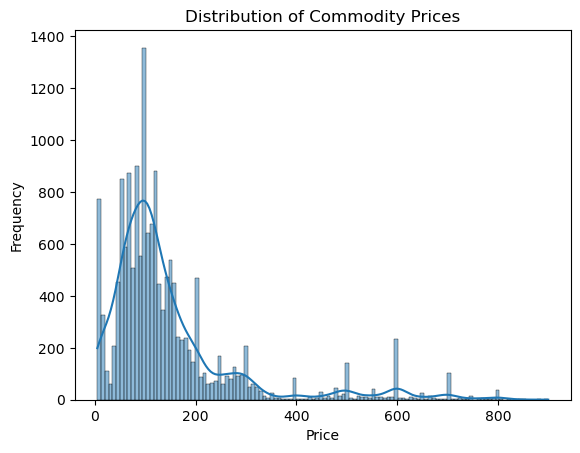

In [78]:
# Visualize the distribution of commodity prices
sns.histplot(data=df, x='price', kde=True)

plt.title('Distribution of Commodity Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


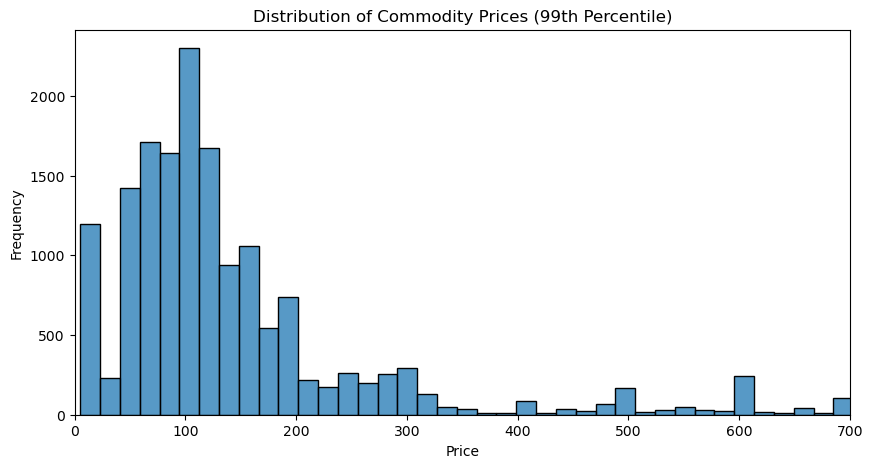

In [79]:
# Visualize the main concentration of commodity prices
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='price',
    bins=50
)

plt.xlim(0, df['price'].quantile(0.99))

plt.title('Distribution of Commodity Prices (99th Percentile)')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.show()

C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


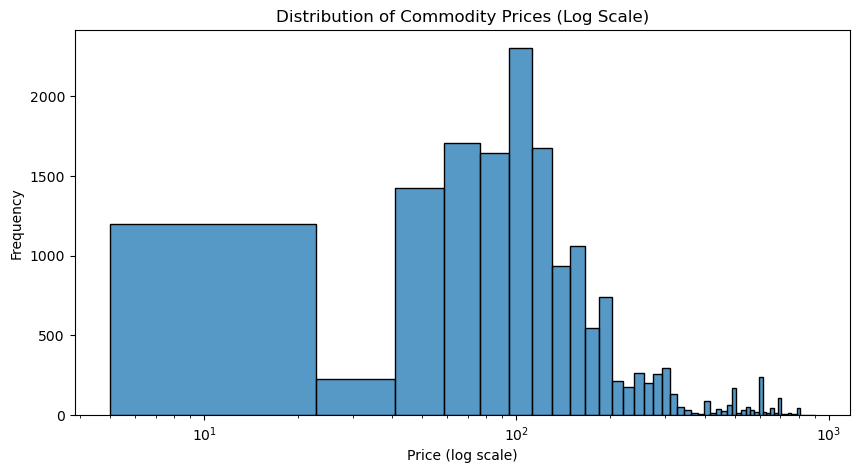

In [80]:
# Since the two graphs above are heavily right-skewed, I will be using log to make the visualization better
# Visualize price distribution using a logarithmic x-axis
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='price',
    bins=50
)

plt.xscale('log')

plt.title('Distribution of Commodity Prices (Log Scale)')
plt.xlabel('Price (log scale)')
plt.ylabel('Frequency')

plt.show()

#### 2. Rainfall distribution

C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


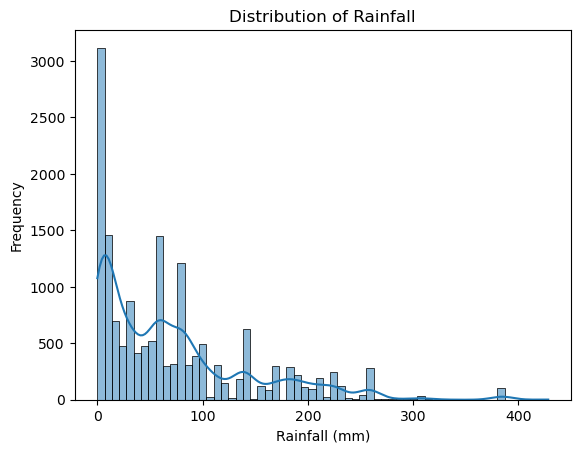

In [81]:
# Visualize the distribution of rainfall observations
sns.histplot(data=df, x='rainfall_mm', kde=True)

plt.title('Distribution of Rainfall')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Frequency')
plt.show()

#### 3. USD price distribution

C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


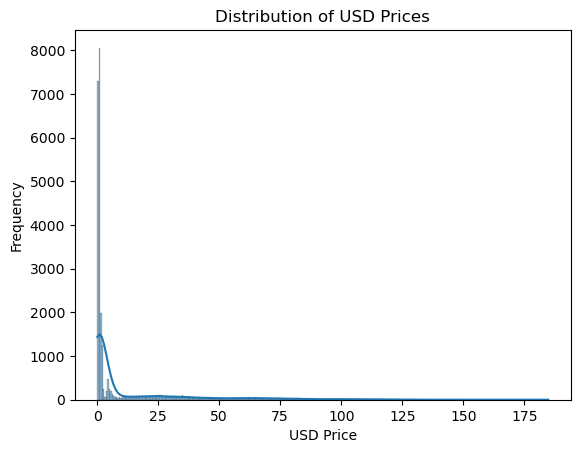

In [46]:
# Visualize the distribution of prices converted to USD
sns.histplot(data=df, x='usd_price', kde=True)

plt.title('Distribution of USD Prices')
plt.xlabel('USD Price')
plt.ylabel('Frequency')
plt.show()

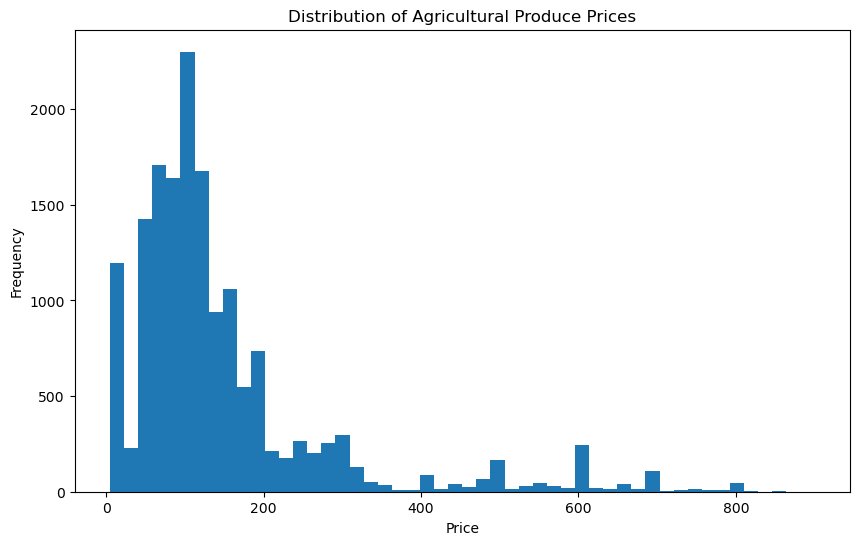

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(df["price"], bins=50)

plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of Agricultural Produce Prices")

plt.show()

#### Exploring trends over time

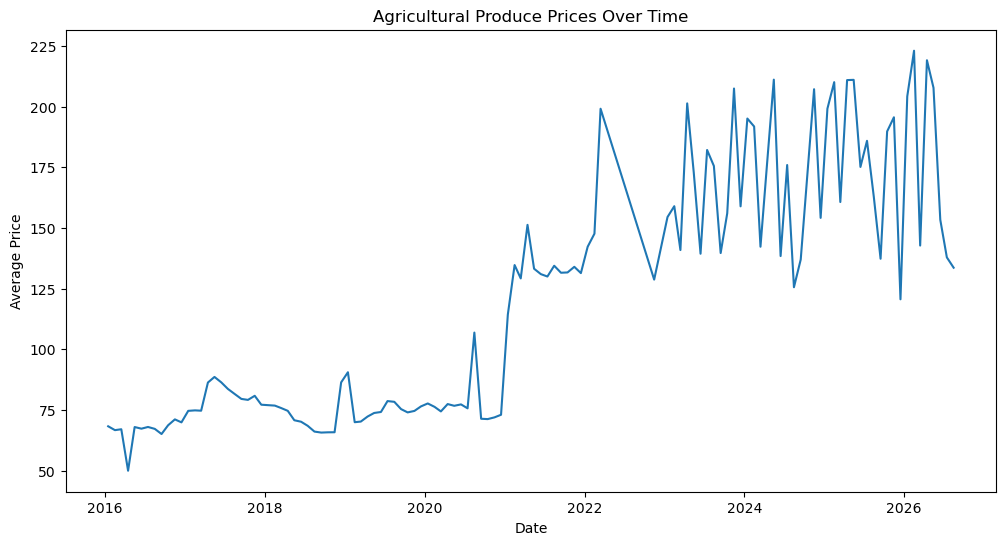

In [83]:
monthly = (
    df.groupby("date")["price"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(12,6))

plt.plot(monthly["date"], monthly["price"])

plt.xlabel("Date")
plt.ylabel("Average Price")
plt.title("Agricultural Produce Prices Over Time")

plt.show()

In [84]:
commodity_prices = (
    df.groupby(["date", "commodity"])["price"]
      .mean()
      .reset_index()
)

In [85]:
df['commodity'].unique()

array(['Beans', 'Beans (dry)', 'Bread', 'Cooking fat', 'Cowpeas (dry)',
       'Kale', 'Maize', 'Maize (white)', 'Maize (white, dry)',
       'Maize flour', 'Maize flour (white)', 'Meat (beef)',
       'Meat (camel)', 'Meat (goat)', 'Milk (UHT)', 'Milk (camel, fresh)',
       'Milk (cow, fresh)', 'Milk (cow, pasteurized)', 'Oil (vegetable)',
       'Oil (vegetable, fortified)', 'Onions (red)', 'Pigeon peas (dry)',
       'Potatoes (Irish)', 'Rice', 'Rice (aromatic)', 'Salt', 'Sorghum',
       'Spinach', 'Sugar', 'Tomatoes', 'Wheat flour'], dtype=object)

### Commodity Coverage Analysis

In [86]:
df['commodity'].value_counts()

commodity
Sugar                         1329
Wheat flour                   1282
Salt                          1215
Beans (dry)                    960
Oil (vegetable)                806
Rice                           746
Maize flour                    726
Maize flour (white)            723
Rice (aromatic)                702
Milk (cow, pasteurized)        700
Maize                          679
Oil (vegetable, fortified)     671
Potatoes (Irish)               648
Milk (UHT)                     640
Beans                          595
Maize (white, dry)             546
Maize (white)                  438
Meat (goat)                    409
Kale                           368
Sorghum                        367
Meat (beef)                    352
Cowpeas (dry)                  292
Meat (camel)                   290
Spinach                        209
Milk (camel, fresh)            146
Cooking fat                    127
Pigeon peas (dry)              111
Bread                           58
Milk (cow,

In [87]:
commodity_summary = (
    df.groupby('commodity')
      .agg(
          observations=('price', 'count'),
          first_date=('date', 'min'),
          last_date=('date', 'max'),
          average_price=('price', 'mean')
      )
      .sort_values('observations', ascending=False)
)

commodity_summary

,observations,first_date,last_date,average_price
commodity,,,,
Sugar,1329,2018-12-15,2026-08-15,157.028247
Wheat flour,1282,2018-12-15,2026-08-15,99.952083
Salt,1215,2018-12-15,2026-08-15,12.480543
Beans (dry),960,2016-01-15,2026-08-15,123.749375
Oil (vegetable),806,2016-01-15,2026-08-15,248.653213
Rice,746,2018-12-15,2026-08-15,120.777989
Maize flour,726,2018-12-15,2026-08-15,82.141598
Maize flour (white),723,2023-12-15,2026-03-15,95.498382
Rice (aromatic),702,2023-12-15,2026-03-15,138.436610


### Defining commodity categories

In [91]:
# Primary agricultural crops
primary_crops = [
    "Beans",
    "Beans (dry)",
    "Cowpeas (dry)",
    "Kale",
    "Maize",
    "Maize (white)",
    "Maize (white, dry)",
    "Onions (red)",
    "Pigeon peas (dry)",
    "Potatoes (Irish)",
    "Rice",
    "Rice (aromatic)",
    "Sorghum",
    "Spinach",
    "Tomatoes"
]

# Animal agricultural products
animal_products = [
    "Meat (beef)",
    "Meat (camel)",
    "Meat (goat)",
    "Milk (camel, fresh)",
    "Milk (cow, fresh)",
    "Milk (cow, pasteurized)",
    "Milk (UHT)"
]

# Processed food products
processed_foods = [
    "Bread",
    "Maize flour",
    "Maize flour (white)",
    "Wheat flour",
    "Oil (vegetable)",
    "Oil (vegetable, fortified)",
    "Cooking fat"
]

# Other food commodities
other_foods = [
    "Sugar",
    "Salt"
]

In [92]:
def classify_commodity(commodity):

    if commodity in primary_crops:
        return "Primary Crop"

    elif commodity in animal_products:
        return "Animal Product"

    elif commodity in processed_foods:
        return "Processed Food"

    elif commodity in other_foods:
        return "Other Food Commodity"

    else:
        return "Unclassified"

In [93]:
df["commodity_type"] = df["commodity"].apply(classify_commodity)

In [94]:
df[["commodity", "commodity_type"]].drop_duplicates().sort_values("commodity")

,commodity,commodity_type
0,Beans,Primary Crop
595,Beans (dry),Primary Crop
1555,Bread,Processed Food
1613,Cooking fat,Processed Food
1740,Cowpeas (dry),Primary Crop
2032,Kale,Primary Crop
2400,Maize,Primary Crop
3079,Maize (white),Primary Crop
3517,"Maize (white, dry)",Primary Crop
4063,Maize flour,Processed Food


In [96]:
# checking the number of observations per category
df["commodity_type"].value_counts()

commodity_type
Primary Crop            6663
Processed Food          4393
Animal Product          2563
Other Food Commodity    2544
Name: count, dtype: int64

In [104]:
# since our model is only focused on agricultural product prices and not the food product prices, we need to\
#work with agricultural produce alone
agri_df = df[df["commodity_type"] == "Primary Crop"].copy()
agri_df.head(10)

,date,region,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,...,year,season,petrol_price_kes,diesel_price_kes,rolling_3m_avg,rolling_6m_avg,rolling_12m_avg,price_vs_regional_avg,price_label,commodity_type
0,2024-09-15,Coast,Adele Center,10441,-0.47,39.61,pulses and nuts,Beans,50,KG,...,2024,Dry Season,188.84,171.60,160.000000,160.000000,160.000000,1.050687,Average,Primary Crop
1,2024-03-15,North Eastern,Alango Arba,10354,-0.10,39.99,pulses and nuts,Beans,50,KG,...,2024,Long Rains,206.36,196.47,200.000000,200.000000,200.000000,1.097394,Average,Primary Crop
2,2024-06-15,North Eastern,Alango Arba,10354,-0.10,39.99,pulses and nuts,Beans,50,KG,...,2024,Dry Season,189.84,179.30,200.000000,200.000000,200.000000,1.201201,Expensive,Primary Crop
3,2024-09-15,North Eastern,Alango Arba,10354,-0.10,39.99,pulses and nuts,Beans,50,KG,...,2024,Dry Season,188.84,171.60,196.666667,196.666667,196.666667,1.143326,Expensive,Primary Crop
4,2023-12-15,Rift Valley,Alemsekon,10457,3.53,34.82,pulses and nuts,Beans,50,KG,...,2023,Short Rains,212.36,201.47,155.000000,155.000000,155.000000,0.888363,Cheap,Primary Crop
5,2024-03-15,Rift Valley,Alemsekon,10457,3.53,34.82,pulses and nuts,Beans,50,KG,...,2024,Long Rains,206.36,196.47,179.000000,179.000000,179.000000,1.208586,Expensive,Primary Crop
6,2024-06-15,Rift Valley,Alemsekon,10457,3.53,34.82,pulses and nuts,Beans,50,KG,...,2024,Dry Season,189.84,179.30,182.000000,182.000000,182.000000,1.211550,Expensive,Primary Crop
7,2024-09-15,Rift Valley,Alemsekon,10457,3.53,34.82,pulses and nuts,Beans,50,KG,...,2024,Dry Season,188.84,171.60,185.000000,177.500000,177.500000,1.151551,Expensive,Primary Crop
8,2024-03-15,North Eastern,Alinjugur,10362,-0.03,40.46,pulses and nuts,Beans,50,KG,...,2024,Long Rains,206.36,196.47,194.000000,194.000000,194.000000,1.064472,Average,Primary Crop
9,2024-06-15,North Eastern,Alinjugur,10362,-0.03,40.46,pulses and nuts,Beans,50,KG,...,2024,Dry Season,189.84,179.30,193.000000,193.000000,193.000000,1.153153,Expensive,Primary Crop


In [101]:
agri_df.shape

(7886, 28)

In [102]:
agri_df["commodity"].value_counts()

commodity
Beans (dry)            960
Rice                   746
Rice (aromatic)        702
Maize                  679
Potatoes (Irish)       648
Beans                  595
Maize (white, dry)     546
Maize (white)          438
Meat (goat)            409
Kale                   368
Sorghum                367
Meat (beef)            352
Cowpeas (dry)          292
Meat (camel)           290
Spinach                209
Milk (camel, fresh)    146
Pigeon peas (dry)      111
Milk (cow, fresh)       26
Onions (red)             1
Tomatoes                 1
Name: count, dtype: int64

#### Bivariate Analysis

In [132]:
# analyzing the price stats by commodity
df.groupby("commodity")["price"].agg(
    ["count", "mean", "median", "std", "min", "max"]
).sort_values("mean", ascending=False)

,count,mean,median,std,min,max
commodity,,,,,,
Meat (goat),409,624.083301,600.000,113.519962,400.00,900.00
Meat (camel),290,545.758552,592.775,96.732035,400.00,800.00
Meat (beef),352,542.483551,540.000,88.371080,5.00,800.00
"Oil (vegetable, fortified)",671,291.731744,295.000,39.177137,100.00,403.00
Oil (vegetable),806,248.653213,250.000,42.101920,118.33,400.00
Pigeon peas (dry),111,203.387387,175.000,98.235424,87.00,700.00
Cooking fat,127,188.720315,183.330,44.637232,104.00,380.00
Cowpeas (dry),292,160.893836,152.500,52.743372,50.00,600.00
Beans,595,157.079832,155.000,29.702692,88.00,270.00


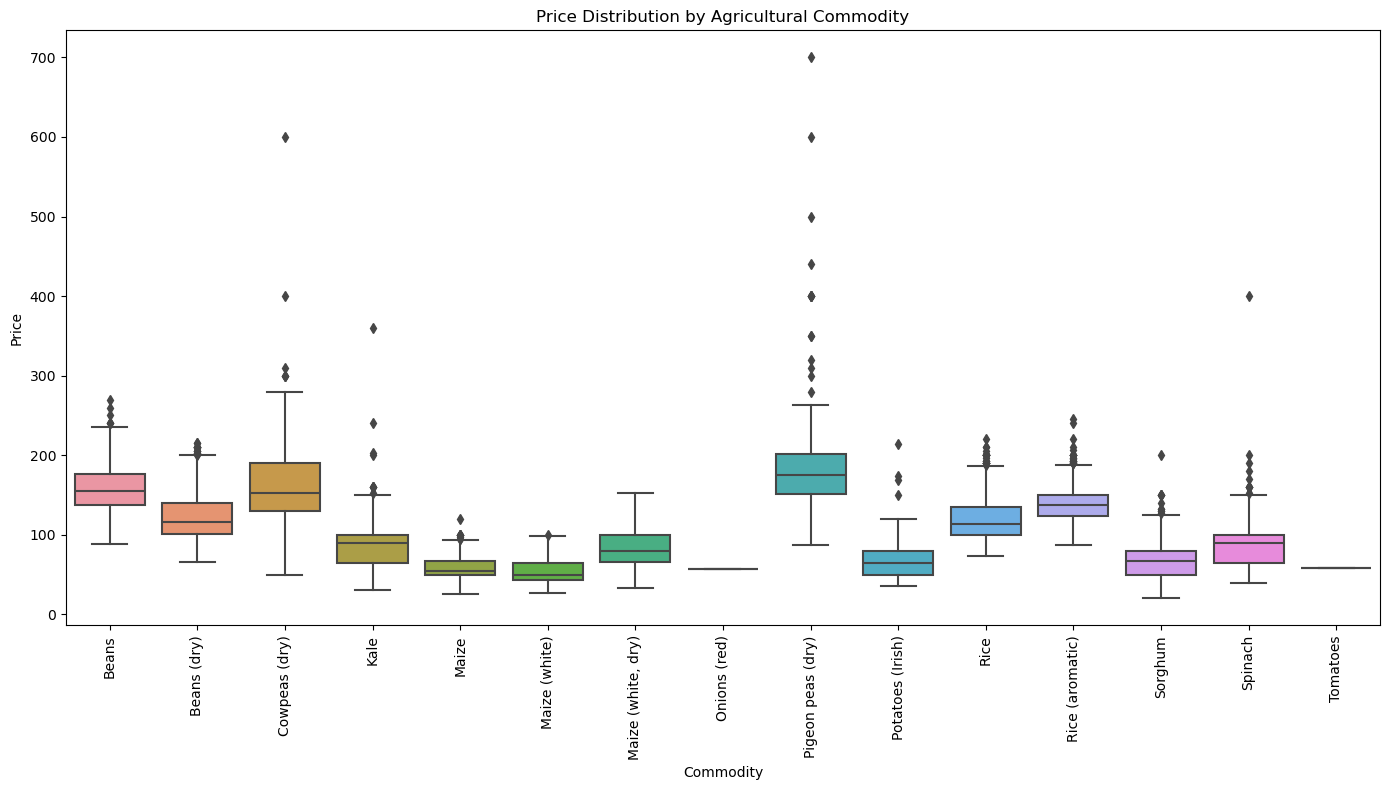

In [147]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))

sns.boxplot(
    data=agri_df,
    x="commodity",
    y="price"
)

plt.xticks(rotation=90)
plt.title("Price Distribution by Agricultural Commodity")
plt.xlabel("Commodity")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


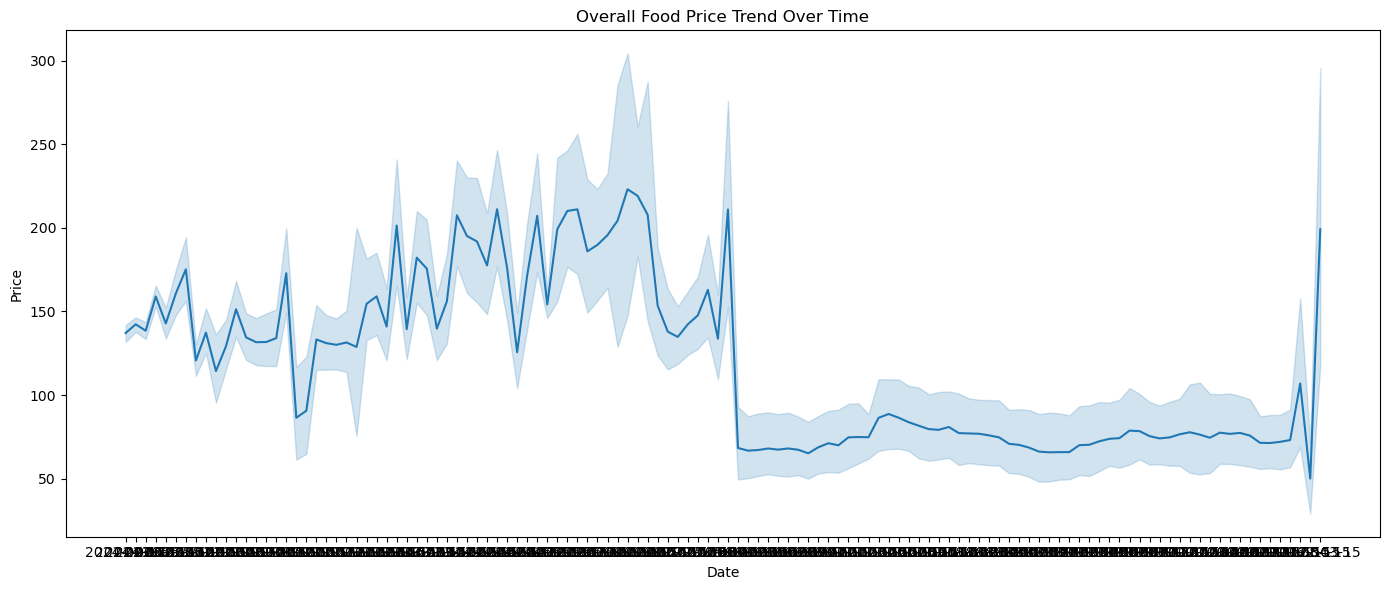

In [146]:
# overall price trend
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=df,
    x="date",
    y="price"
)

plt.title("Overall Food Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Price")

plt.tight_layout()
plt.show()

<Axes: xlabel='commodity', ylabel='price'>

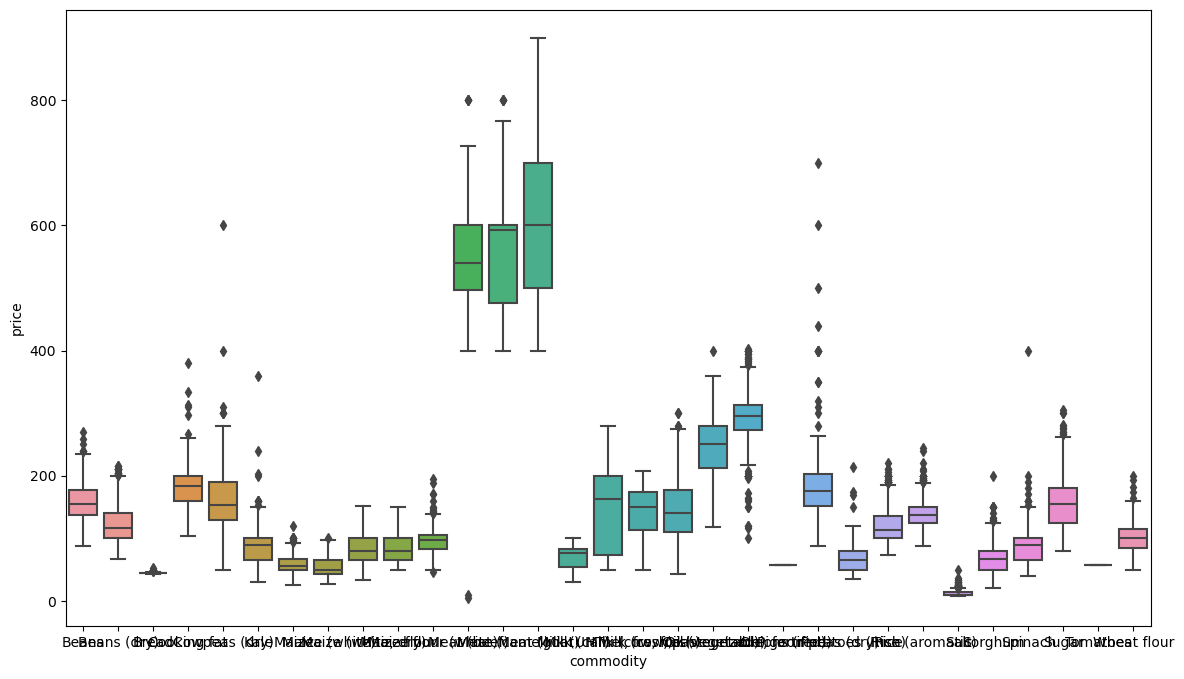

In [134]:
# analyzing commodity vs price
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))

sns.boxplot(
    data= df,
    x="commodity",
    y="price"
)

In [144]:
# price variability by commodity
price_variability = (
    df.groupby("commodity")["price"]
      .agg(["mean", "median", "std", "min", "max"])
      .sort_values("std", ascending=False)
)

price_variability

,mean,median,std,min,max
commodity,,,,,
Meat (goat),624.083301,600.000,113.519962,400.00,900.00
Pigeon peas (dry),203.387387,175.000,98.235424,87.00,700.00
Meat (camel),545.758552,592.775,96.732035,400.00,800.00
Meat (beef),542.483551,540.000,88.371080,5.00,800.00
"Milk (camel, fresh)",145.254452,163.410,61.069828,50.00,280.00
Cowpeas (dry),160.893836,152.500,52.743372,50.00,600.00
"Milk (cow, fresh)",139.079231,150.000,51.369957,50.00,208.00
"Milk (cow, pasteurized)",141.211043,140.000,50.326909,43.00,300.00
Cooking fat,188.720315,183.330,44.637232,104.00,380.00


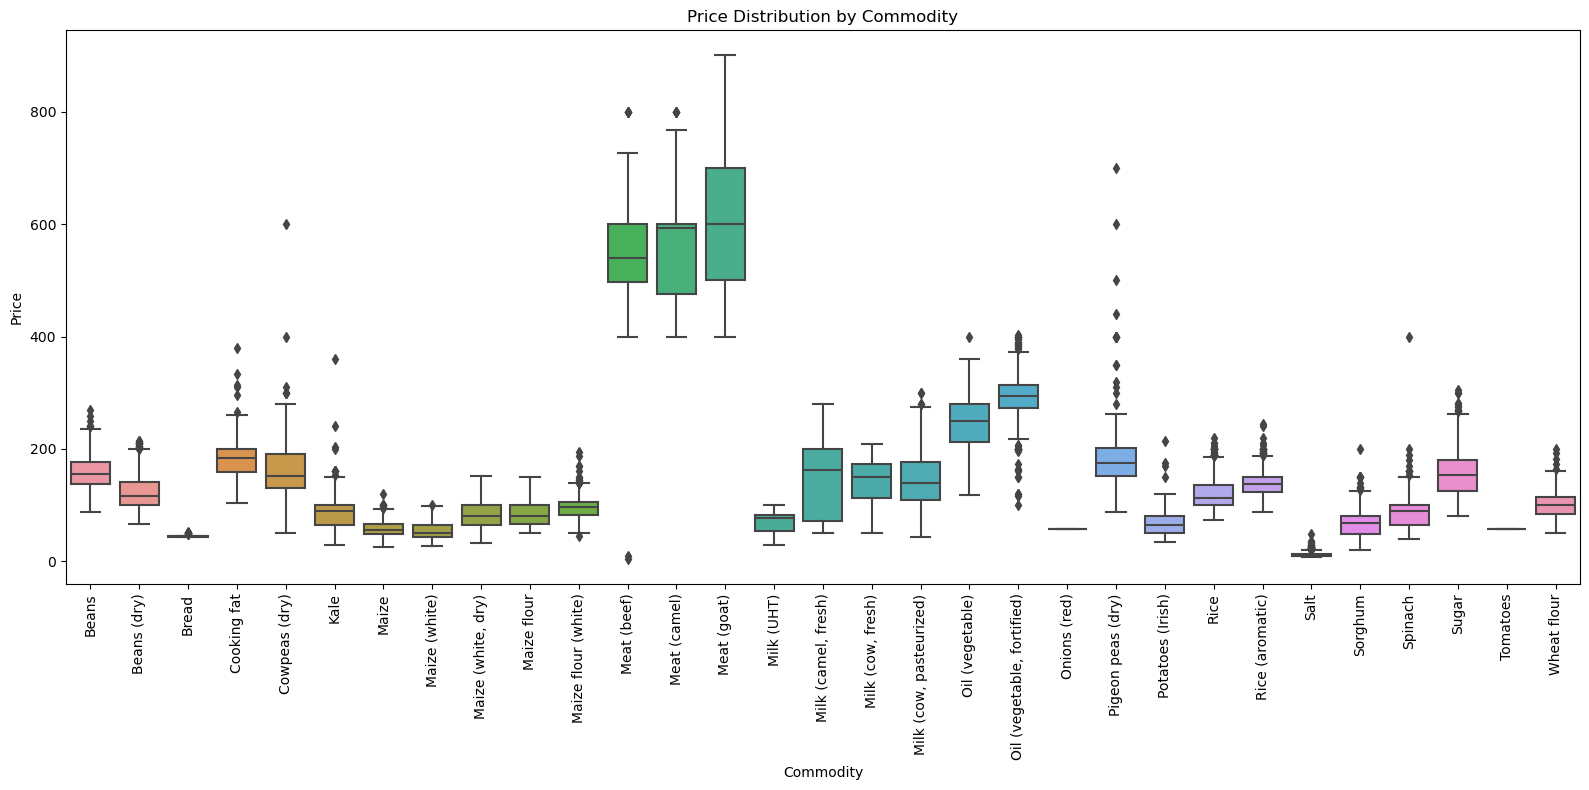

In [145]:
# commodity vs price distribution
plt.figure(figsize=(16, 8))

sns.boxplot(
    data=df,
    x="commodity",
    y="price"
)

plt.title("Price Distribution by Commodity")
plt.xlabel("Commodity")
plt.ylabel("Price")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [135]:
agri_time_df = df[
    df["commodity"].isin(agricultural_commodities)
].copy()

In [136]:
agri_time_df["commodity"].value_counts()

commodity
Beans (dry)            960
Rice                   746
Rice (aromatic)        702
Maize                  679
Potatoes (Irish)       648
Beans                  595
Maize (white, dry)     546
Maize (white)          438
Meat (goat)            409
Kale                   368
Sorghum                367
Meat (beef)            352
Cowpeas (dry)          292
Meat (camel)           290
Spinach                209
Milk (camel, fresh)    146
Pigeon peas (dry)      111
Milk (cow, fresh)       26
Onions (red)             1
Tomatoes                 1
Name: count, dtype: int64

C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


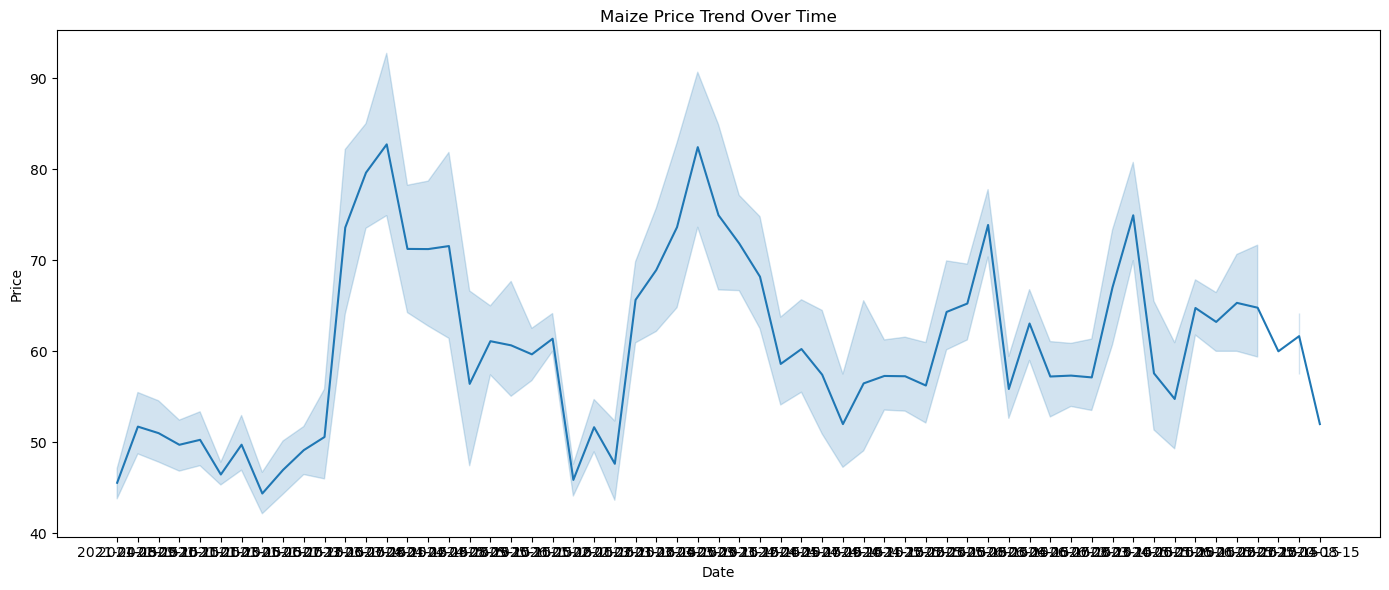

In [137]:
maize = agri_time_df[
    agri_time_df["commodity"] == "Maize"
]

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=maize,
    x="date",
    y="price"
)

plt.title("Maize Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Price")

plt.tight_layout()
plt.show()

C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


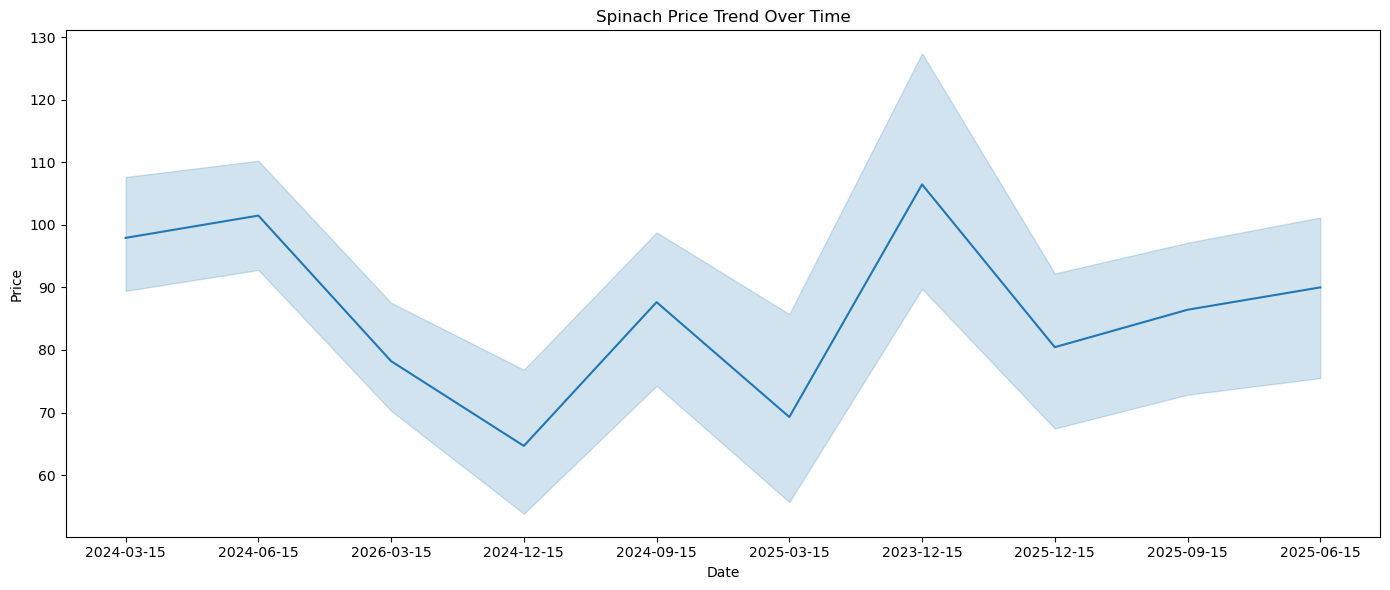

In [141]:
spinach = agri_time_df[
    agri_time_df["commodity"] == "Spinach"
]

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=spinach,
    x="date",
    y="price"
)

plt.title("Spinach Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Price")

plt.tight_layout()
plt.show()

C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


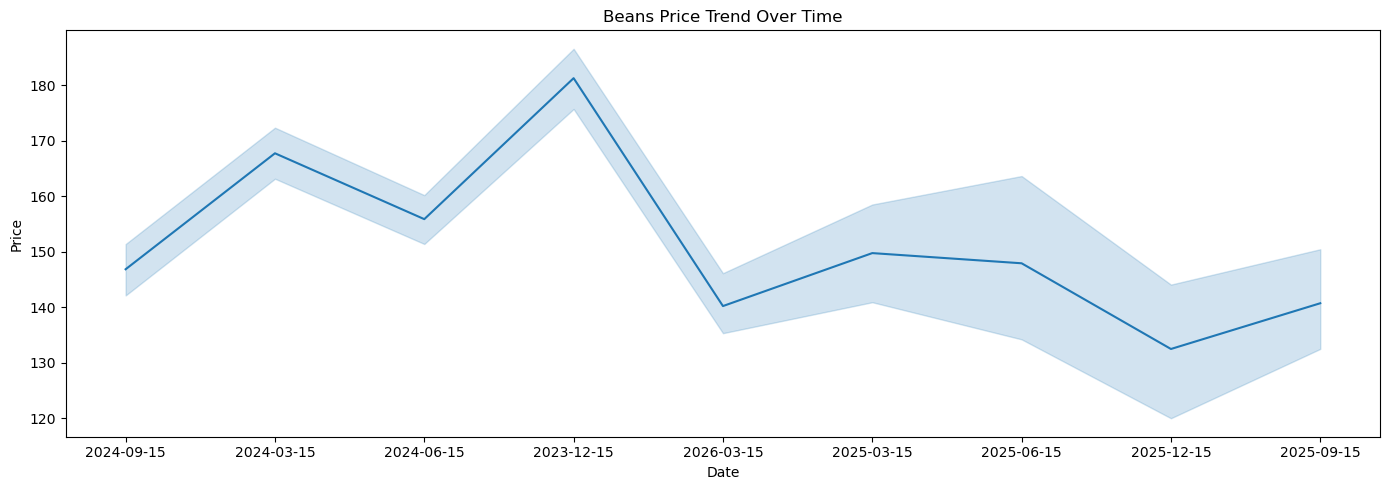

C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


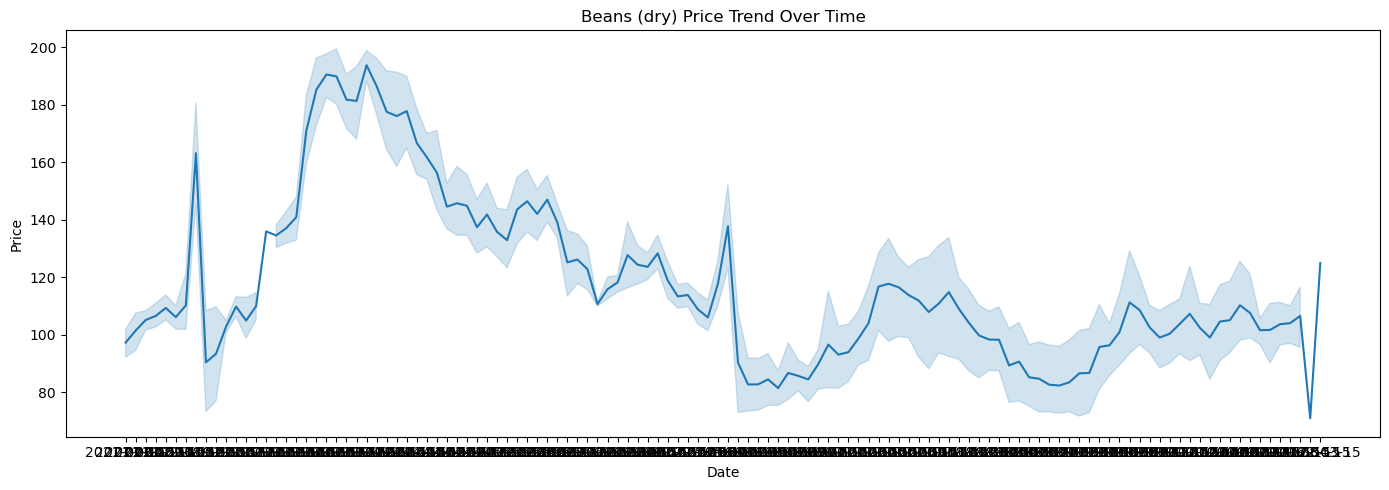

C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


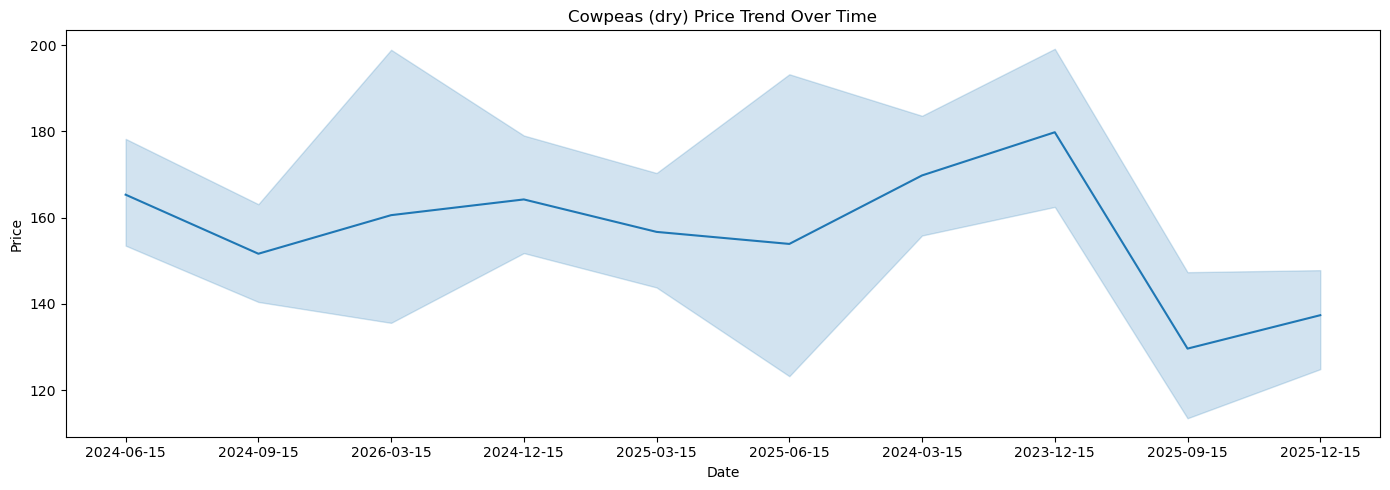

C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


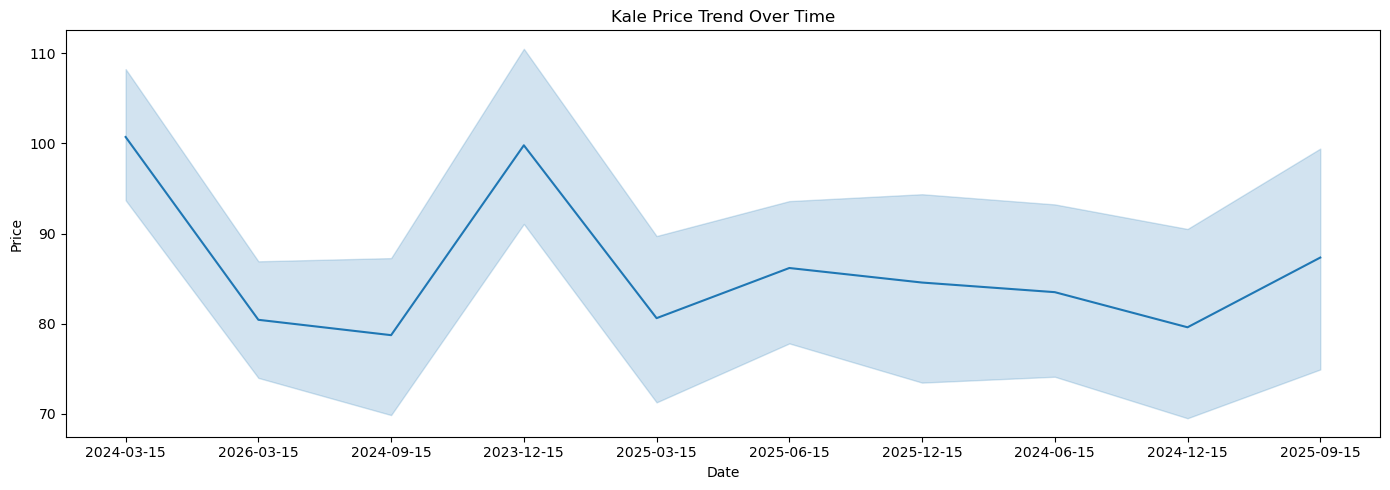

C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


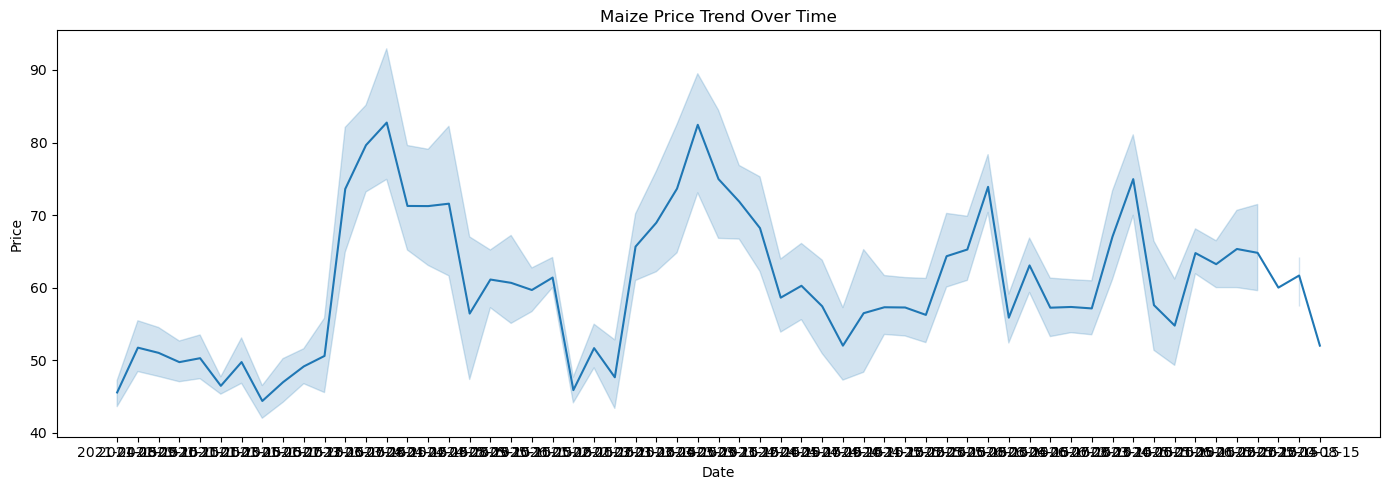

C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


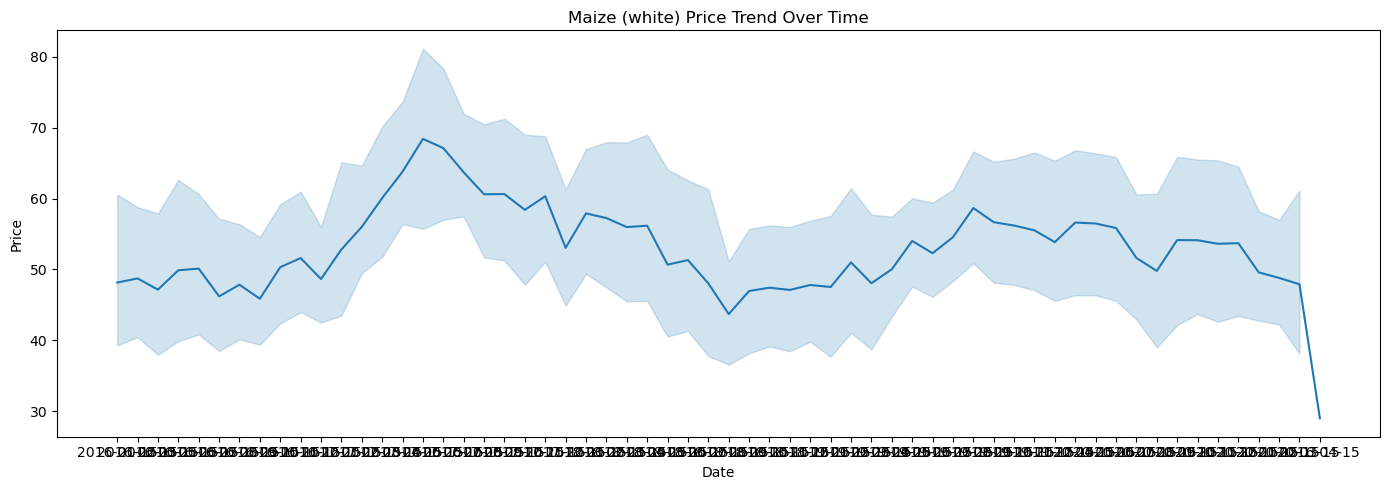

C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


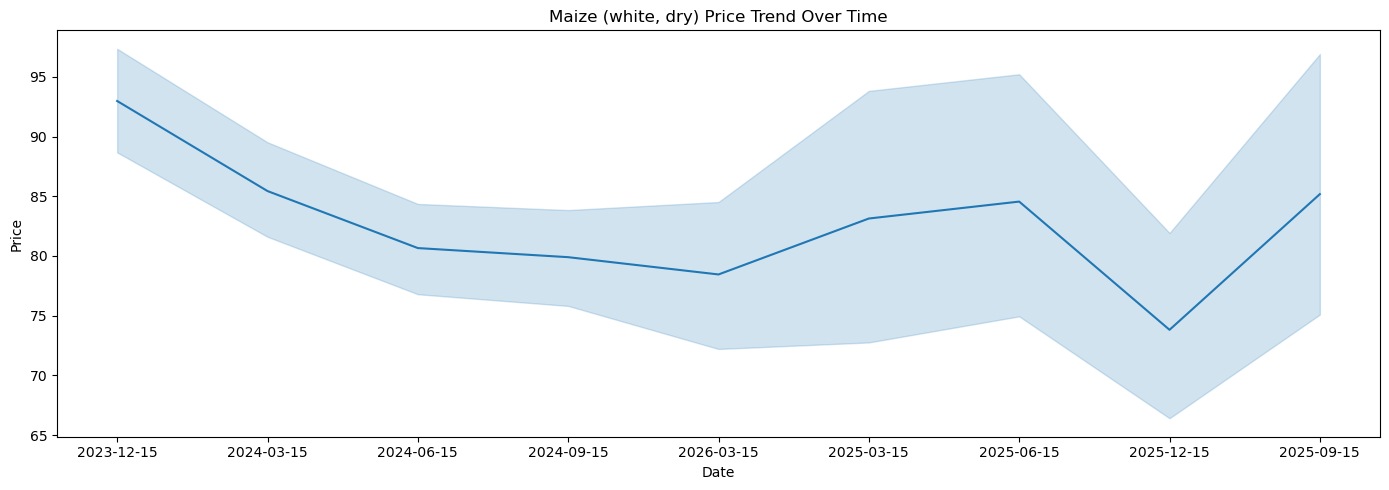

C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


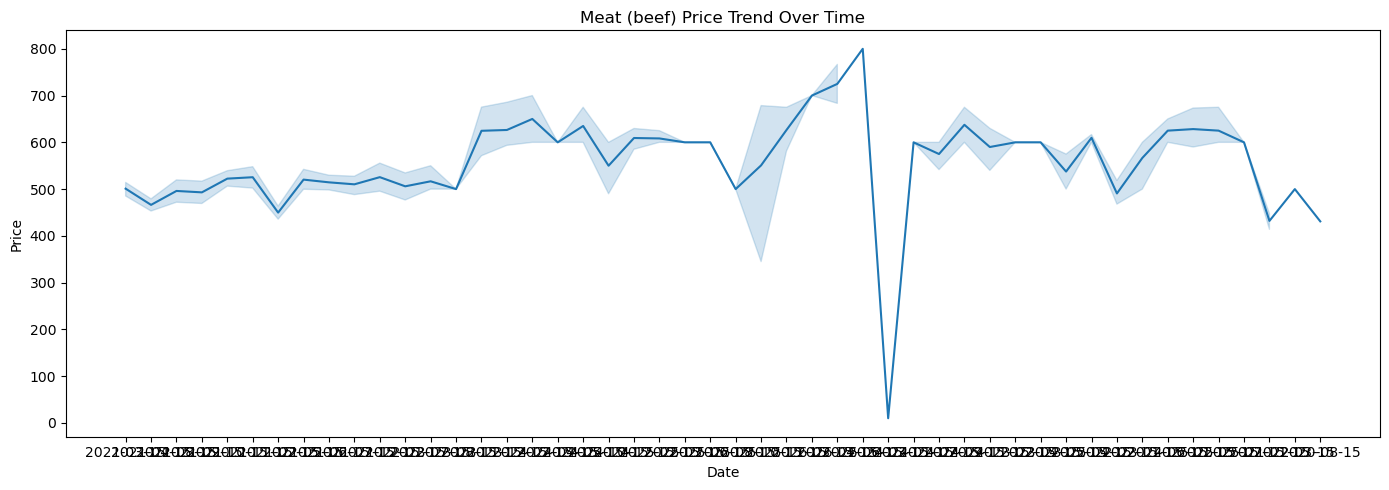

C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


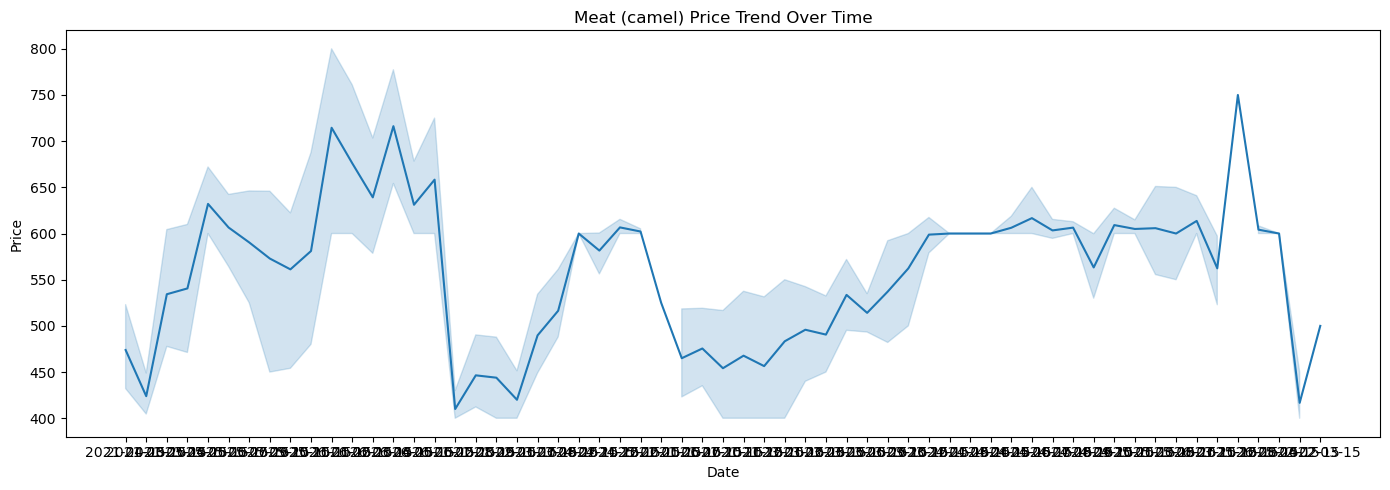

C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


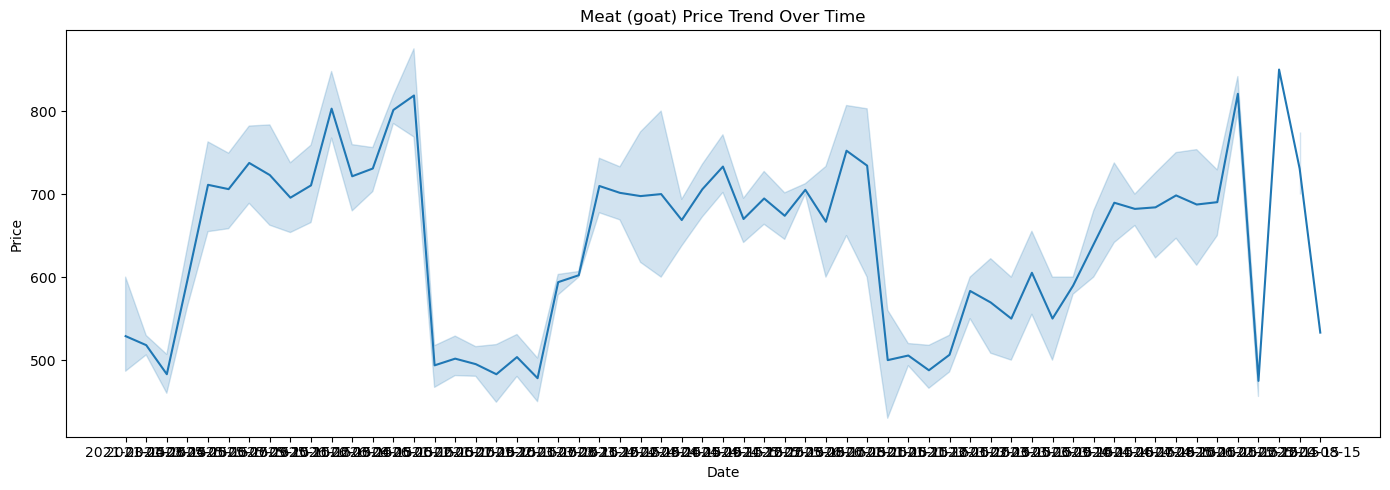

C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


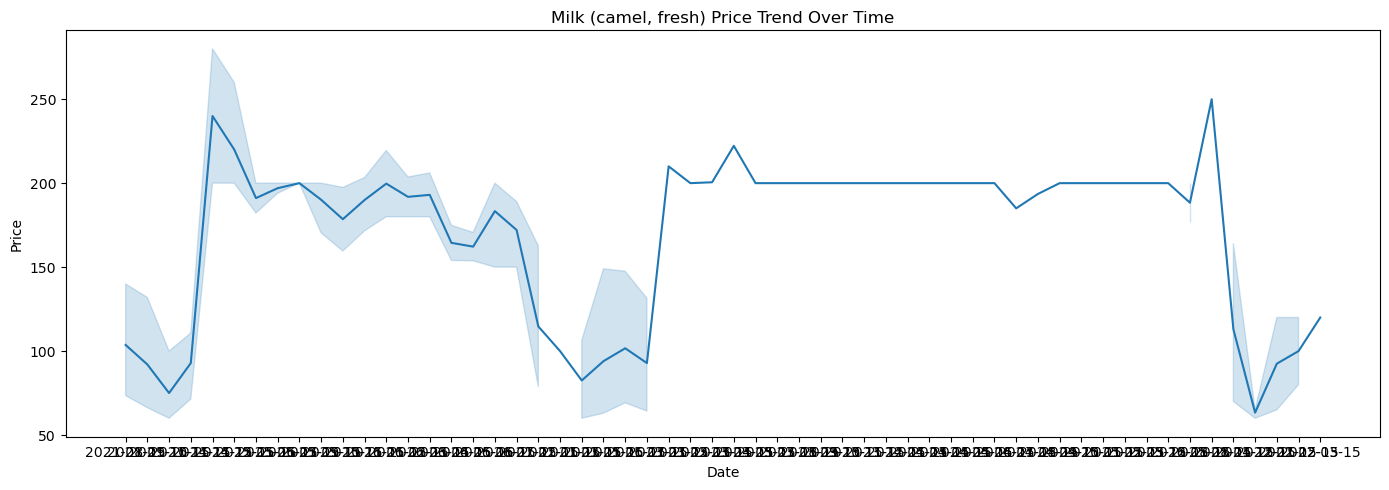

C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


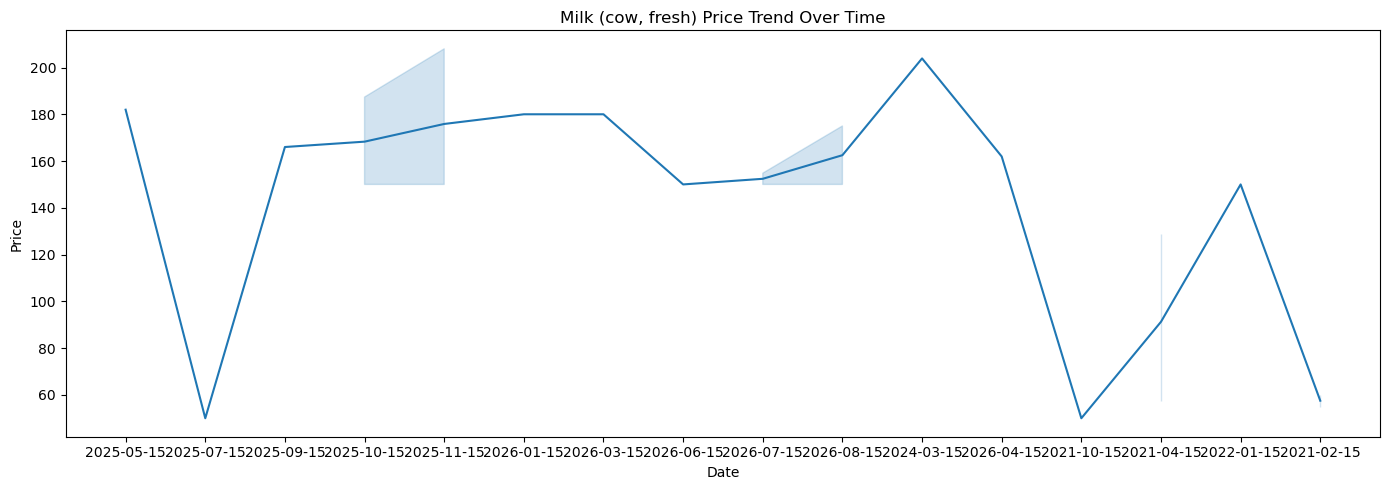

C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


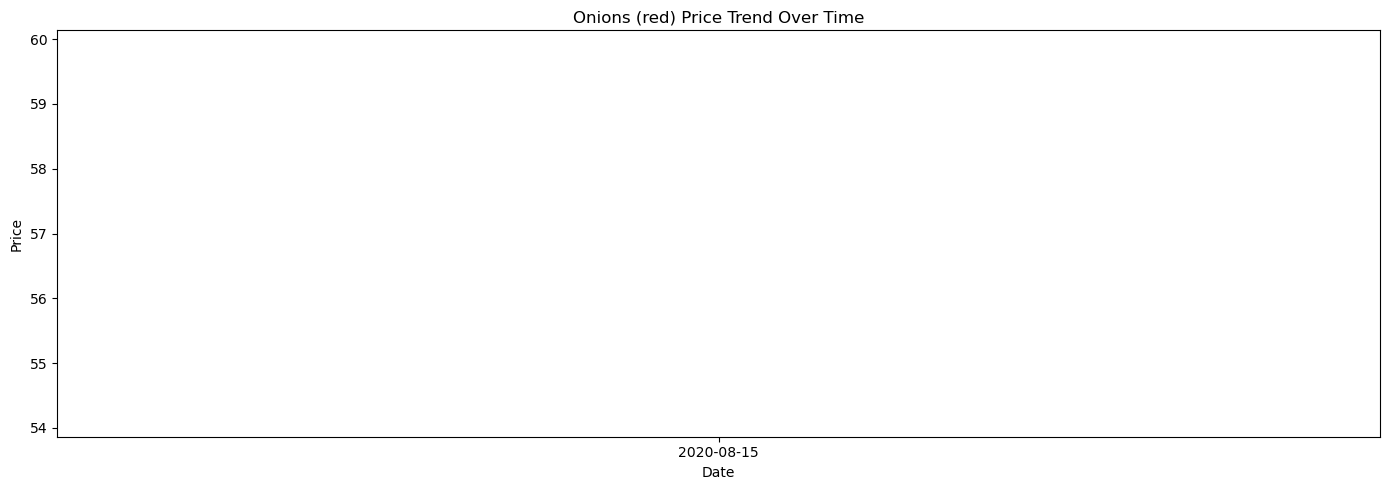

C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


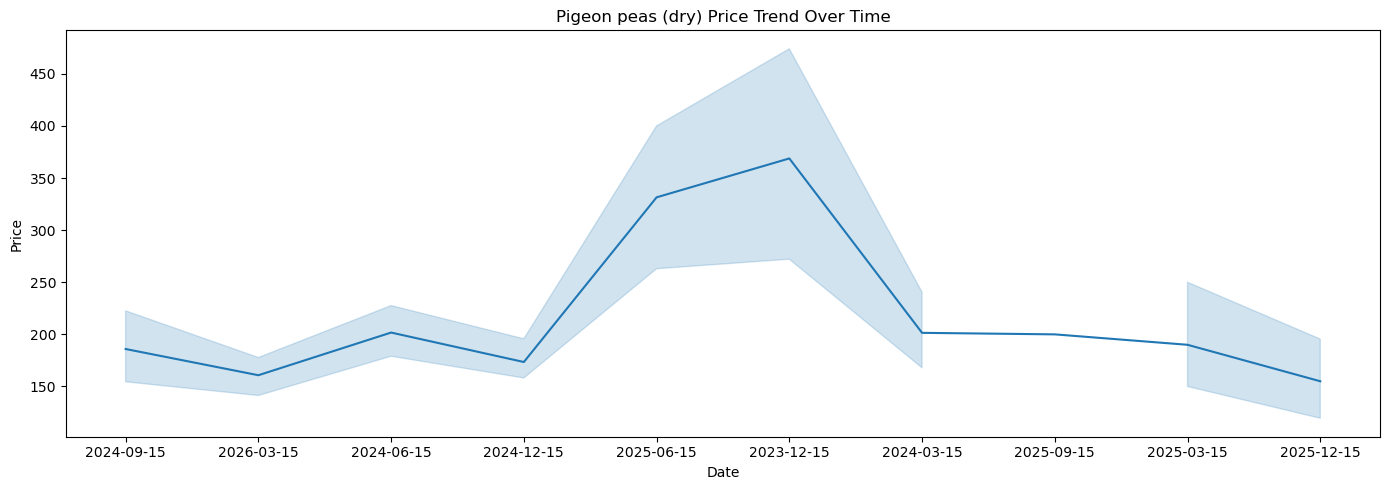

C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


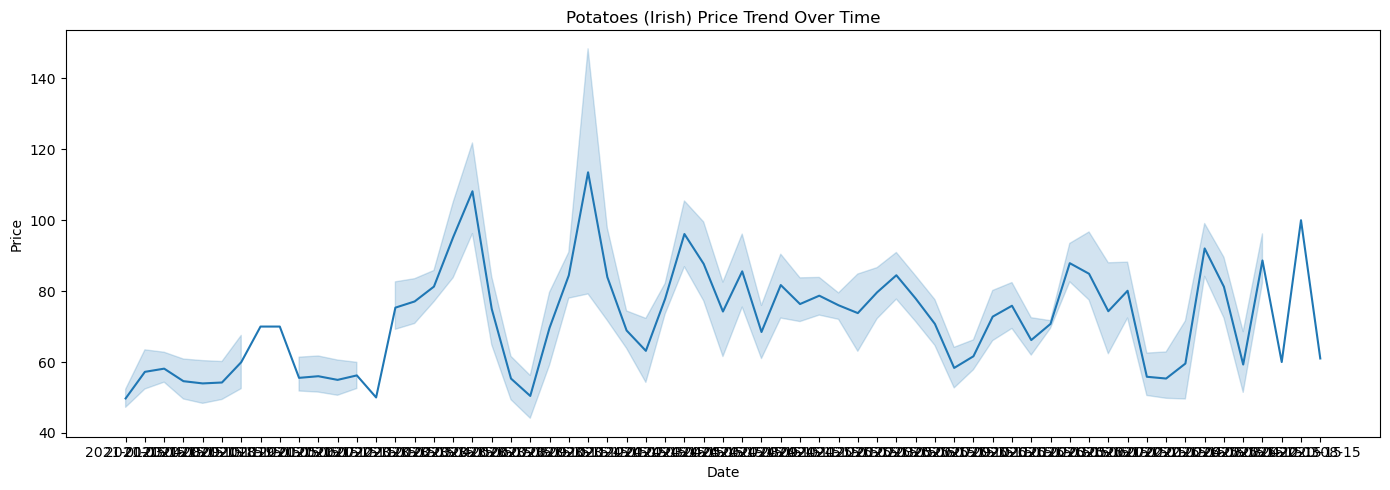

C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


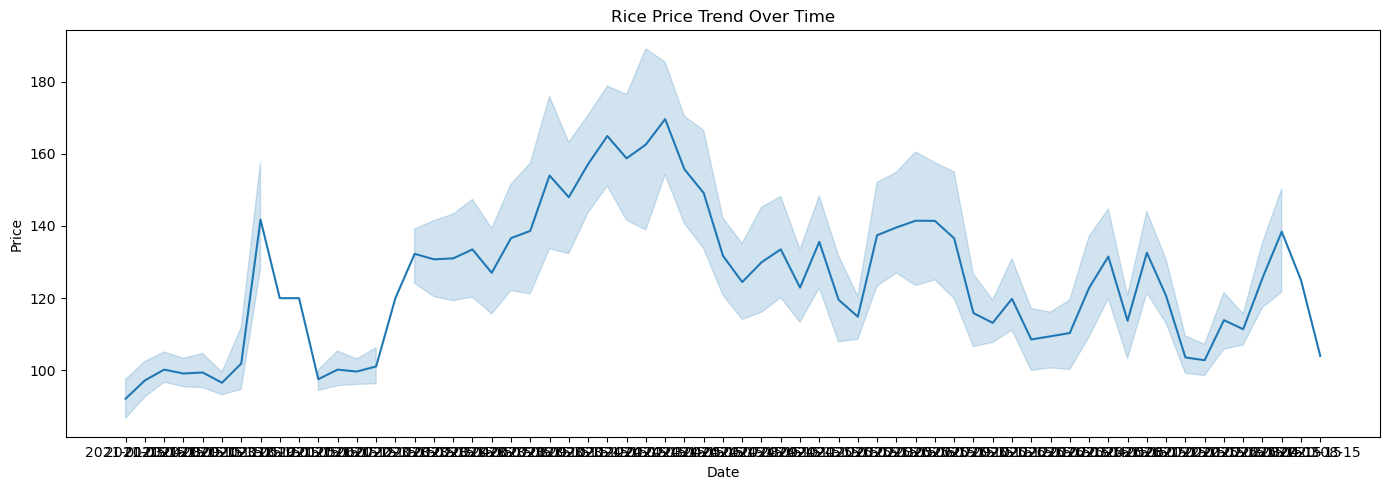

C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


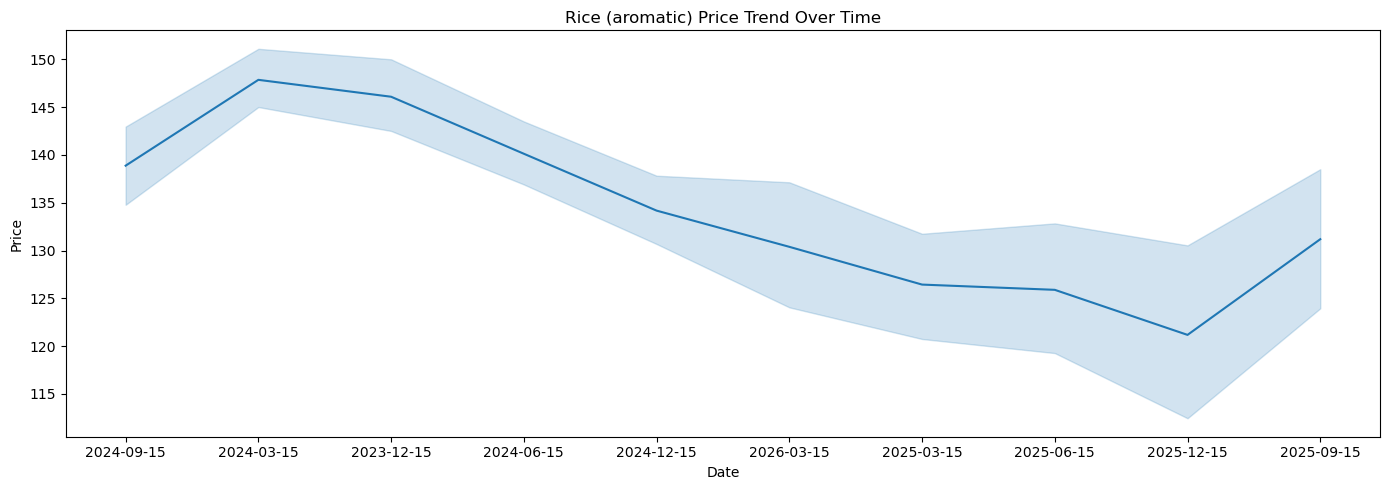

C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


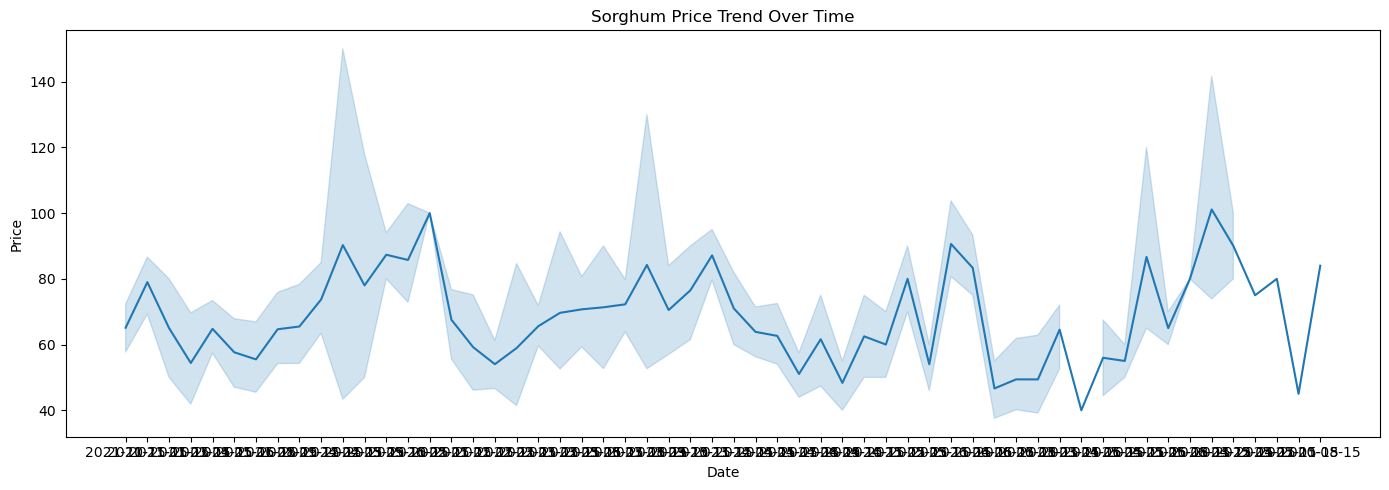

C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


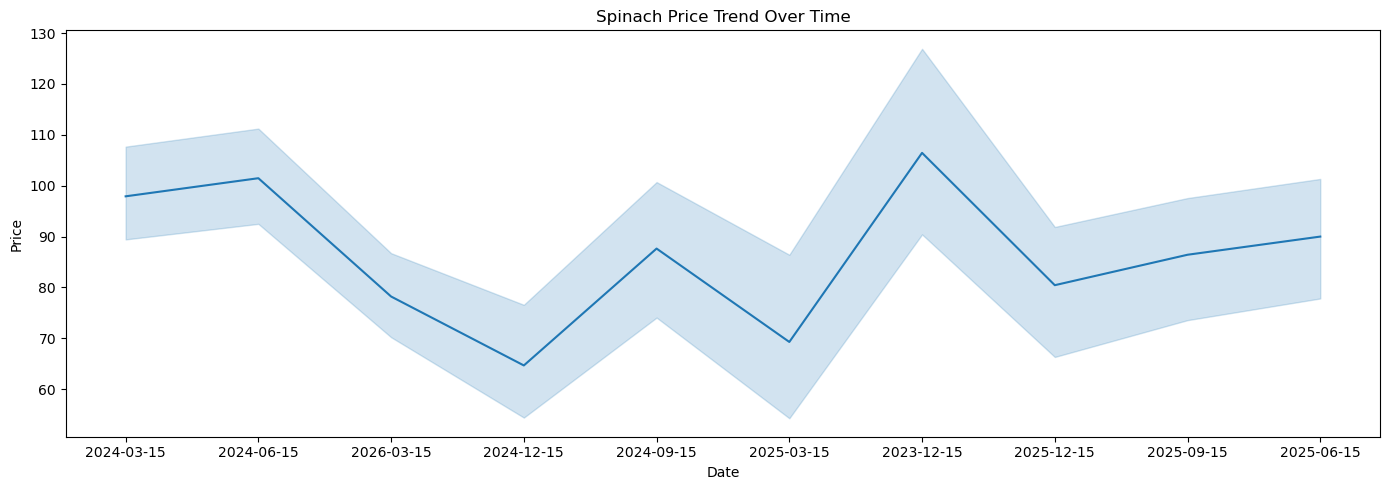

C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\admin\anaconda3\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


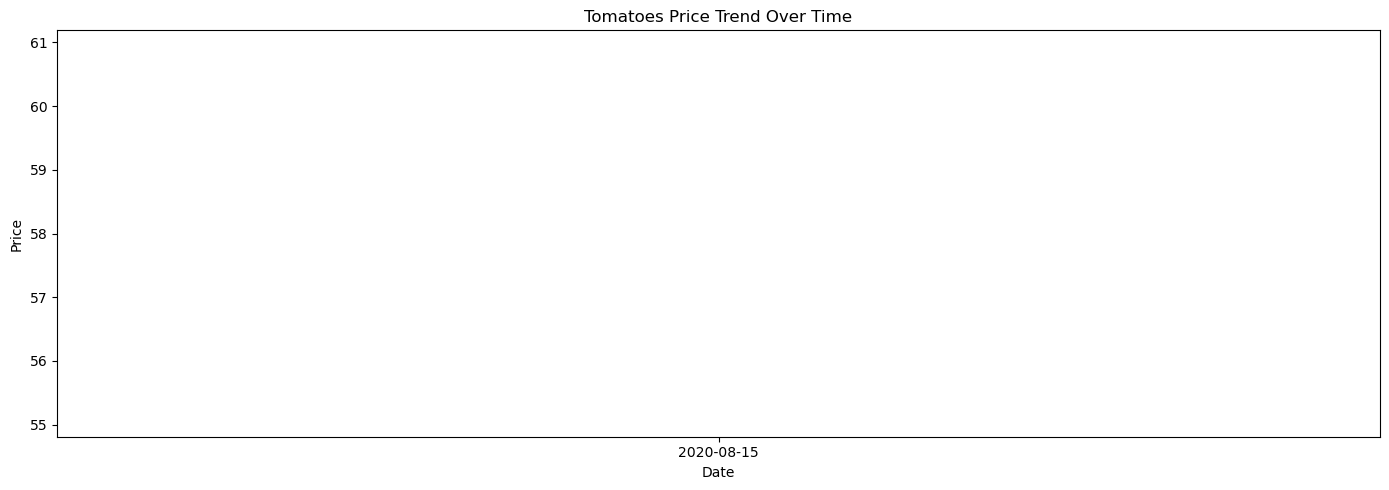

In [140]:
for commodity in agri_time_df["commodity"].unique():

    commodity_data = agri_time_df[
        agri_time_df["commodity"] == commodity
    ]

    plt.figure(figsize=(14, 5))

    sns.lineplot(
        data=commodity_data,
        x="date",
        y="price"
    )

    plt.title(f"{commodity} Price Trend Over Time")
    plt.xlabel("Date")
    plt.ylabel("Price")

    plt.tight_layout()
    plt.show()

### Analyzing feature Correlations

In [148]:
#### Checking numerical columns
df.select_dtypes(include="number").columns

Index(['market_id', 'latitude', 'longitude', 'commodity_id', 'price',
       'usdprice', 'rainfall_mm', 'price_per_kg', 'month', 'year',
       'petrol_price_kes', 'diesel_price_kes', 'rolling_3m_avg',
       'rolling_6m_avg', 'rolling_12m_avg', 'price_vs_regional_avg'],
      dtype='object')

In [149]:
correlation_matrix = df.select_dtypes(include="number").corr()

correlation_matrix

,market_id,latitude,longitude,commodity_id,price,usdprice,rainfall_mm,price_per_kg,month,year,petrol_price_kes,diesel_price_kes,rolling_3m_avg,rolling_6m_avg,rolling_12m_avg,price_vs_regional_avg
market_id,1.000000,-0.116098,0.174434,1.997970e-01,-0.021104,-0.055097,-1.881701e-01,-0.032715,1.024594e-01,3.567480e-01,4.398081e-01,4.202648e-01,-0.022886,-0.016065,-0.009115,6.208643e-02
latitude,-0.116098,1.000000,-0.691224,-2.008679e-02,0.092188,0.062344,3.690922e-01,0.103561,1.282641e-02,3.053244e-01,3.061852e-01,2.948415e-01,0.104737,0.103776,0.100332,7.331322e-02
longitude,0.174434,-0.691224,1.000000,7.588074e-02,-0.038744,-0.037876,-5.287307e-01,-0.053607,2.286683e-02,-2.642961e-03,6.021407e-03,1.187582e-02,-0.048529,-0.044500,-0.039293,-2.866031e-03
commodity_id,0.199797,-0.020087,0.075881,1.000000e+00,0.118854,0.104320,-8.081223e-02,0.152740,4.659821e-02,1.666066e-01,1.681309e-01,1.625006e-01,0.157100,0.160356,0.165857,1.486518e-15
price,-0.021104,0.092188,-0.038744,1.188544e-01,1.000000,0.988955,2.918380e-02,0.989379,-8.944355e-03,1.249056e-01,1.137291e-01,1.104830e-01,0.982917,0.979793,0.976260,1.260504e-01
usdprice,-0.055097,0.062344,-0.037876,1.043201e-01,0.988955,1.000000,2.505262e-02,0.978546,-3.209793e-02,5.933360e-02,1.501038e-02,1.242549e-02,0.972520,0.970727,0.969430,1.209751e-01
rainfall_mm,-0.188170,0.369092,-0.528731,-8.081223e-02,0.029184,0.025053,1.000000e+00,0.036398,1.119153e-01,-1.033523e-01,-9.697398e-03,-2.737231e-02,0.037413,0.037572,0.031483,1.344542e-16
price_per_kg,-0.032715,0.103561,-0.053607,1.527399e-01,0.989379,0.978546,3.639807e-02,1.000000,-1.103611e-02,1.253632e-01,1.122684e-01,1.091590e-01,0.991923,0.988146,0.984218,1.409164e-01
month,0.102459,0.012826,0.022867,4.659821e-02,-0.008944,-0.032098,1.119153e-01,-0.011036,1.000000e+00,-5.591388e-02,1.307122e-01,1.031033e-01,-0.010018,-0.004230,-0.002987,-1.398250e-17
year,0.356748,0.305324,-0.002643,1.666066e-01,0.124906,0.059334,-1.033523e-01,0.125363,-5.591388e-02,1.000000e+00,7.953600e-01,7.925010e-01,0.133413,0.138872,0.142622,8.132393e-15


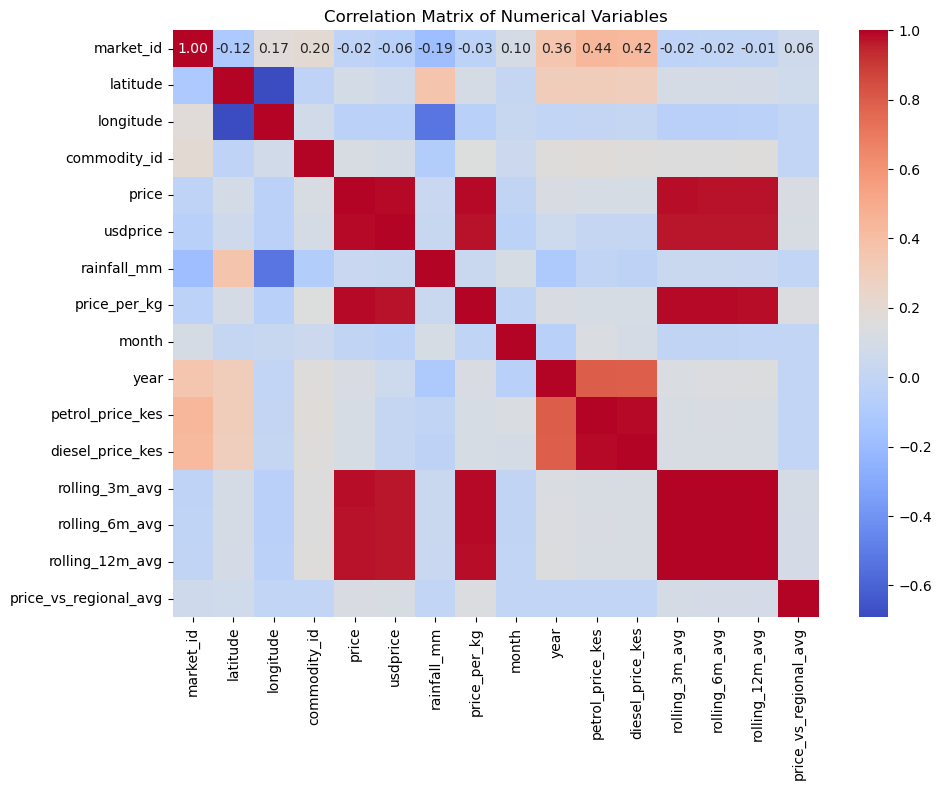

In [150]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

### Finding the values most correlated with price

In [151]:
price_correlation = (
    correlation_matrix["price"]
    .sort_values(ascending=False)
)

price_correlation

price                    1.000000
price_per_kg             0.989379
usdprice                 0.988955
rolling_3m_avg           0.982917
rolling_6m_avg           0.979793
rolling_12m_avg          0.976260
price_vs_regional_avg    0.126050
year                     0.124906
commodity_id             0.118854
petrol_price_kes         0.113729
diesel_price_kes         0.110483
latitude                 0.092188
rainfall_mm              0.029184
month                   -0.008944
market_id               -0.021104
longitude               -0.038744
Name: price, dtype: float64

In [152]:
price_correlation.abs().sort_values(ascending=False)

price                    1.000000
price_per_kg             0.989379
usdprice                 0.988955
rolling_3m_avg           0.982917
rolling_6m_avg           0.979793
rolling_12m_avg          0.976260
price_vs_regional_avg    0.126050
year                     0.124906
commodity_id             0.118854
petrol_price_kes         0.113729
diesel_price_kes         0.110483
latitude                 0.092188
longitude                0.038744
rainfall_mm              0.029184
market_id                0.021104
month                    0.008944
Name: price, dtype: float64

#### Rainfall vs price commodity correlations

In [153]:
commodity_correlations = []

for commodity in df["commodity"].unique():

    temp = df[df["commodity"] == commodity]

    correlation = temp["price"].corr(temp["rainfall_mm"])

    commodity_correlations.append({
        "commodity": commodity,
        "rainfall_price_correlation": correlation
    })

correlation_df = pd.DataFrame(commodity_correlations)

correlation_df.sort_values(
    "rainfall_price_correlation",
    ascending=False
)

C:\Users\admin\anaconda3\New folder\Lib\site-packages\numpy\lib\function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
C:\Users\admin\anaconda3\New folder\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
C:\Users\admin\anaconda3\New folder\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


,commodity,rainfall_price_correlation
14,Milk (UHT),0.395759
23,Rice,0.316826
21,Pigeon peas (dry),0.223845
1,Beans (dry),0.200334
28,Sugar,0.174446
22,Potatoes (Irish),0.135394
18,Oil (vegetable),0.119959
17,"Milk (cow, pasteurized)",0.092736
7,Maize (white),0.091709
9,Maize flour,0.076911


#### Correlation Analysis

The correlation analysis was conducted to examine the linear relationship between agricultural produce prices and the numerical variables available in the dataset. As expected, price_per_kg and usdprice showed very strong positive correlations with price (0.989 and 0.989 respectively), while the 3-, 6-, and 12-month rolling price averages also showed strong correlations. These variables are derived from the original price variable and therefore were not considered independent predictors.

Among the potential external factors, petrol price (0.114), diesel price (0.110), and year (0.125) showed weak positive relationships with price. In contrast, rainfall had a very weak overall correlation with price (0.029), suggesting that there is little evidence of a simple linear relationship between rainfall and prices across the entire dataset.

However, this finding does not necessarily mean that rainfall is unimportant for price forecasting. The dataset contains multiple commodities and markets, and the effect of rainfall may differ by commodity, location, and season. In addition, weather conditions may affect agricultural prices with a time lag rather than during the same period. Therefore, further analysis will examine commodity-specific correlations, seasonal patterns, and lagged relationships between rainfall and agricultural produce prices.